# Testing Depth Anything alone

## Setup

In [1]:
import os
from pathlib import Path
import sys
import json
# import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm
from dataset import TrainDataset

import matplotlib.pyplot as plt

# warnings.filterwarnings('ignore')

In [2]:
PROJECT_ROOT = Path('..')
TRAIN_DIR = PROJECT_ROOT / 'data/train'

DA_ROOT = PROJECT_ROOT / 'external' / 'Depth-Anything-V2' / 'metric_depth'
DEPTH_ANYTHING_MODEL = 'vitl' # or 'vits', 'vitb', 'vitl'
DA_DATASET = 'vkitti' # 'hypersim' for indoor model, 'vkitti' for outdoor model
DA_MAX_DEPTH = 80 # 20 for indoor model, 80 for outdoor model
DA_CHECKPOINT = PROJECT_ROOT / 'checkpoints' / f'depth_anything_v2_metric_{DA_DATASET}_{DEPTH_ANYTHING_MODEL}.pth'

VAL_FRAC = 0.10
SPLIT_SEED = 42
SPLIT_DIR = PROJECT_ROOT / 'splits'
SPLIT_PATH = SPLIT_DIR / f'train_val_split_seed{SPLIT_SEED}_val{int(VAL_FRAC * 100)}.json'

BATCH_SIZE = 4
NUM_WORKERS = 4
EPS = 1e-6

RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
SPLIT_DIR.mkdir(exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'Split file: {SPLIT_PATH}')

Device: cuda
Split file: ../splits/train_val_split_seed42_val10.json


In [3]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
def make_or_load_split(train_dataset):
    n = len(train_dataset)

    if SPLIT_PATH.exists():
        with open(SPLIT_PATH, 'r') as f:
            split = json.load(f)

        train_indices = split['train_indices']
        val_indices = split['val_indices']

        print(f'Loaded split from {SPLIT_PATH}')

    else:
        rng = np.random.default_rng(SPLIT_SEED)
        all_indices = np.arange(n)
        rng.shuffle(all_indices)

        val_size = int(n * VAL_FRAC)
        val_indices = sorted(all_indices[:val_size].tolist())
        train_indices = sorted(all_indices[val_size:].tolist())

        split = {
            'dataset_size': n,
            'val_fraction': VAL_FRAC,
            'seed': SPLIT_SEED,
            'train_size': len(train_indices),
            'val_size': len(val_indices),
            'train_indices': train_indices,
            'val_indices': val_indices
        }

        with open(SPLIT_PATH, 'w') as f:
            json.dump(split, f)

        print(f'Created and saved split to {SPLIT_PATH}')

    return train_indices, val_indices

train_dataset = TrainDataset(str(TRAIN_DIR))
train_indices, val_indices = make_or_load_split(train_dataset)

train_set = Subset(train_dataset, train_indices)
val_set = Subset(train_dataset, val_indices)

Loaded split from ../splits/train_val_split_seed42_val10.json


In [5]:
val_loader = DataLoader(val_set,
                        batch_size=BATCH_SIZE,
                        shuffle=False,
                        num_workers=NUM_WORKERS,
                        pin_memory=True)

In [6]:
!mkdir -d ../external
%cd ../external
!git clone https://github.com/DepthAnything/Depth-Anything-V2.git
%cd Depth-Anything-V2/metric_depth
!python -m pip install -r requirements.txt
%cd ../../../src

/home/raphael/Documents/FS26/CIL/Project/external
fatal: destination path 'Depth-Anything-V2' already exists and is not an empty directory.
/home/raphael/Documents/FS26/CIL/Project/external/Depth-Anything-V2/metric_depth
/home/raphael/Documents/FS26/CIL/Project/src


In [7]:
if str(DA_ROOT) not in sys.path:
    sys.path.append(str(DA_ROOT))

from depth_anything_v2.dpt import DepthAnythingV2

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64,  'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]}
}

da_model = DepthAnythingV2(**{**model_configs[DEPTH_ANYTHING_MODEL], 'max_depth': DA_MAX_DEPTH})
da_model.load_state_dict(torch.load(DA_CHECKPOINT, map_location='cpu'))
da_model = da_model.to(DEVICE).eval()

print(f"Loaded DepthAnythingV2-{DEPTH_ANYTHING_MODEL} from {DA_CHECKPOINT}")

xFormers not available
xFormers not available


Loaded DepthAnythingV2-vitl from ../checkpoints/depth_anything_v2_metric_vkitti_vitl.pth


In [8]:
def squeeze_depth(x):
    if x.ndim == 4 and x.shape[1] == 1:
        x = x[:, 0]
    return x

def resize_pred_to_target(pred, target):
    pred = squeeze_depth(pred)
    target = squeeze_depth(target)

    if pred.shape[-2:] != target.shape[-2:]:
        pred = F.interpolate(pred[:, None],
                             size=target.shape[-2:],
                             mode='bilinear',
                             align_corners=False,)[:,0]
    return pred, target

def valid_mask(target, min_depth=1e-3, max_depth=80.0):
    return (
        torch.isfinite(target)
        & (target >= min_depth)
        & (target <= max_depth)
    )

def scale_invariant_rmse(pred, target, eps=EPS):
    pred, target = resize_pred_to_target(pred, target)
    mask = valid_mask(target, eps)

    pred = torch.clamp(pred,  min=eps)
    target = torch.clamp(target, min=eps)

    d = torch.log(pred[mask]) - torch.log(target[mask])
    return torch.sqrt(torch.mean(d**2) - torch.mean(d) ** 2)

def median_align(pred, target, eps=EPS):
    pred, target = resize_pred_to_target(pred, target)
    aligned = pred.clone()

    for b in range(pred.shape[0]):
        mask = valid_mask(target[b], eps)
        if mask.any():
            pred_med = torch.median(torch.clamp(pred[b][mask], min=eps))
            target_med = torch.median(torch.clamp(target[b][mask], min=eps))
            aligned[b] = pred[b] * (target_med / torch.clamp(pred_med, min=eps))

    return aligned

def compute_metrics(pred, target, eps=EPS):
    pred, target = resize_pred_to_target(pred, target)
    mask = valid_mask(target, eps)

    pred = torch.clamp(pred, min=eps)
    target = torch.clamp(target, min=eps)

    p = pred[mask]
    t = target[mask]

    thresh = torch.maximum(t / p, p / t)

    return {
        'si_rmse': scale_invariant_rmse(pred, target, eps).item(),
        'abs_rel': torch.mean(torch.abs(t - p) / t).item(),
        'mae': torch.mean(torch.abs(t - p)).item(),
        'rmse': torch.sqrt(torch.mean((t - p) ** 2)).item(),
        'delta1': torch.mean((thresh < 1.25).float()).item(),
        'delta2': torch.mean((thresh < 1.25 ** 2).float()).item(),
        'delta3': torch.mean((thresh < 1.25 ** 3).float()).item()
    }

def prefix_dict(d, prefix):
    return {f'{prefix}_{k}': v for k, v in d.items()}

## Base Depth Anything

In [9]:
per_image_rows = []
summary_accumulator = []
seen = 0
NORMALIZE_IMAGES_FOR_DA = True
da_model.eval()

with torch.no_grad():
    for batch in tqdm(val_loader, desc='Evaluating DepthAnythingV2 on val split'):
        images = batch['image'].to(DEVICE, non_blocking=True)
        targets = batch['depth'].to(DEVICE, non_blocking=True)

        images_for_da = images / 255.0 if NORMALIZE_IMAGES_FOR_DA else images
        preds = da_model(images_for_da)
        preds, targets = resize_pred_to_target(preds, targets)

        preds_median = median_align(preds, targets)

        batch_raw = compute_metrics(preds, targets)
        batch_median = compute_metrics(preds_median, targets)
        summary_accumulator.append({
            'batch_size': images.shape[0],
            **prefix_dict(batch_raw, 'raw'),
            **prefix_dict(batch_median, 'median'),
        })

        # Per-image metrics. The DataLoader is not shuffled, so this maps back to val_indices in order.
        for i in range(images.shape[0]):
            global_index = val_indices[seen + i]
            raw_i = compute_metrics(preds[i:i+1], targets[i:i+1])
            med_i = compute_metrics(preds_median[i:i+1], targets[i:i+1])
            per_image_rows.append({
                'global_index': global_index,
                **prefix_dict(raw_i, 'raw'),
                **prefix_dict(med_i, 'median'),
            })

        seen += images.shape[0]

per_image_df = pd.DataFrame(per_image_rows)
per_image_df.head()

Evaluating DepthAnythingV2 on val split:   0%|          | 0/565 [00:00<?, ?it/s]

,global_index,raw_si_rmse,raw_abs_rel,raw_mae,raw_rmse,raw_delta1,raw_delta2,raw_delta3,median_si_rmse,median_abs_rel,median_mae,median_rmse,median_delta1,median_delta2,median_delta3
0,15,6.858411,66.136040,19.573385,19.619110,0.000000,0.000000,0.000000,6.858410,11.500936,0.558912,0.889982,0.940840,0.952969,0.960076
1,41,6.126588,9.623629,6.273045,7.027018,0.092881,0.505893,0.905187,6.126587,5.907115,1.431196,2.409179,0.812049,0.928615,0.940884
2,43,8.955040,0.808070,21.442286,22.581402,0.170829,0.234434,0.525615,8.955040,0.931605,14.046185,22.117468,0.569705,0.893579,0.979335
3,74,7.470619,8.547369,32.386543,32.600792,0.000000,0.000000,0.000000,7.470619,0.878346,0.395884,1.000390,0.963430,0.974754,0.980107
4,102,6.327377,40.121361,15.348424,15.404922,0.000000,0.000000,0.000000,6.327382,7.411010,0.352114,0.838338,0.913608,0.931872,0.942305


In [14]:
# Weighted average over batches, weighted by batch size.
batch_df = pd.DataFrame(summary_accumulator)
metric_cols = [c for c in batch_df.columns if c != 'batch_size']

summary = {
    'model': f'DepthAnythingV2-{DEPTH_ANYTHING_MODEL}',
    'checkpoint': str(DA_CHECKPOINT),
    'split_path': str(SPLIT_PATH),
    'dataset_size': len(train_dataset),
    'val_size': len(val_set),
    'normalize_images_for_da': NORMALIZE_IMAGES_FOR_DA,
}

for col in metric_cols:
    summary[col] = np.average(batch_df[col], weights=batch_df['batch_size'])

summary_df = pd.DataFrame([summary])
summary_df.T

,0
model,DepthAnythingV2-vitl
checkpoint,../checkpoints/depth_anything_v2_metric_vkitti...
split_path,../splits/train_val_split_seed42_val10.json
dataset_size,22605
val_size,2260
normalize_images_for_da,True
raw_si_rmse,7.644072
raw_abs_rel,28.116685
raw_mae,15.654558
raw_rmse,18.290776


In [11]:
summary_path = RESULTS_DIR / f'depthanything_{DEPTH_ANYTHING_MODEL}_val_summary.csv'
per_image_path = RESULTS_DIR / f'depthanything_{DEPTH_ANYTHING_MODEL}_val_per_image.csv'
json_summary_path = RESULTS_DIR / f'depthanything_{DEPTH_ANYTHING_MODEL}_val_summary.json'

summary_df.to_csv(summary_path, index=False)
per_image_df.to_csv(per_image_path, index=False)

with open(json_summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f'Saved summary:   {summary_path}')
print(f'Saved per-image: {per_image_path}')
print(f'Saved JSON:      {json_summary_path}')

Saved summary:   ../results/depthanything_vitl_val_summary.csv
Saved per-image: ../results/depthanything_vitl_val_per_image.csv
Saved JSON:      ../results/depthanything_vitl_val_summary.json


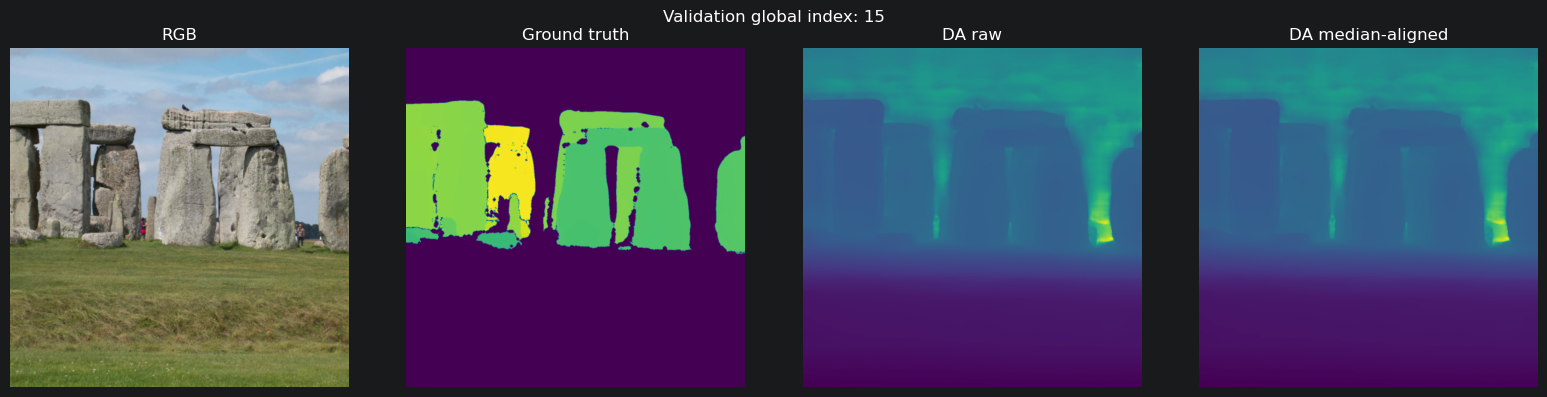

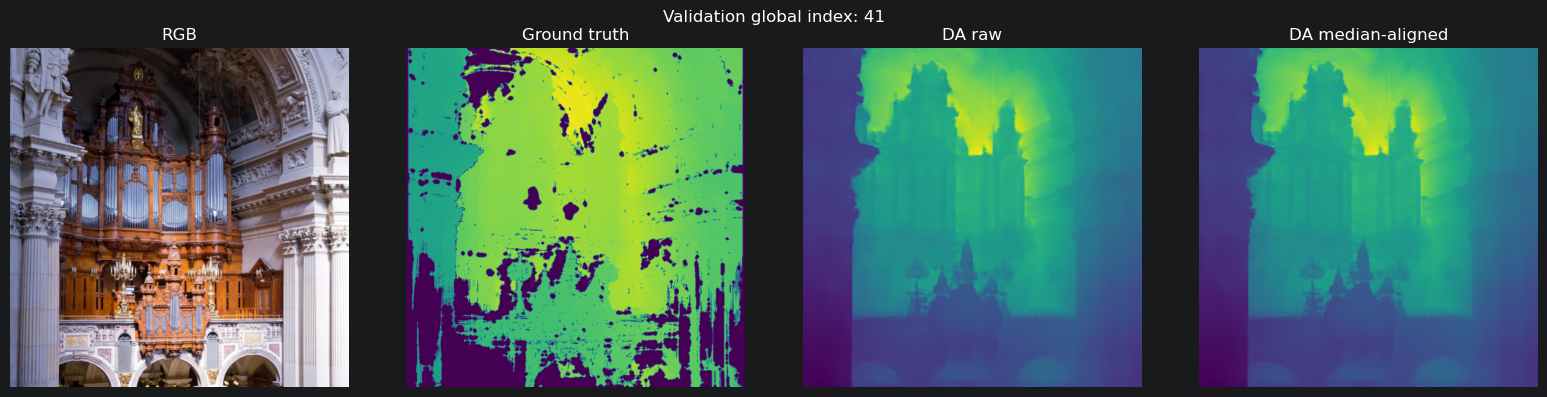

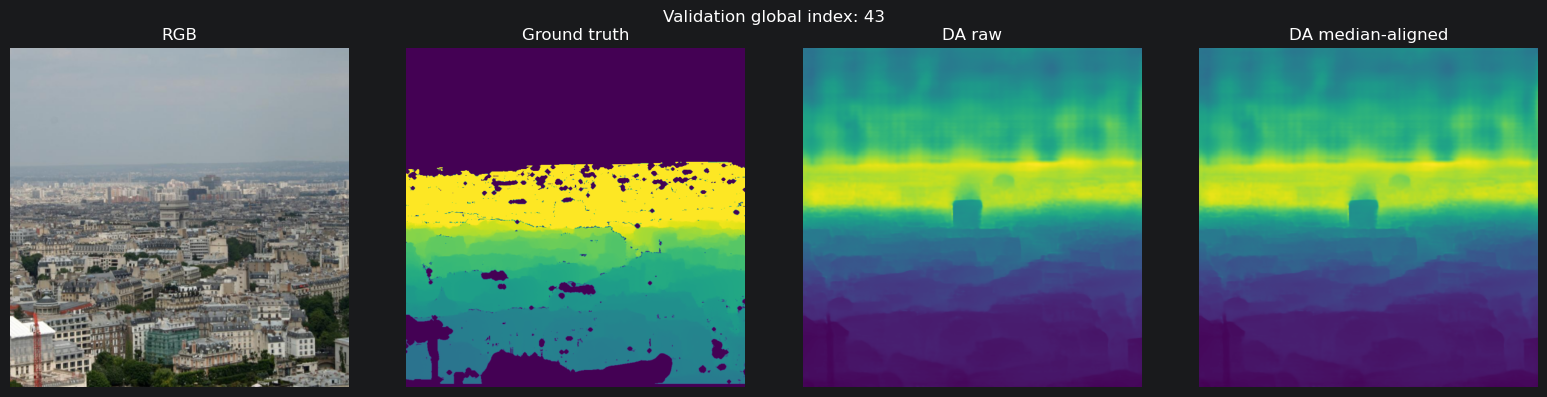

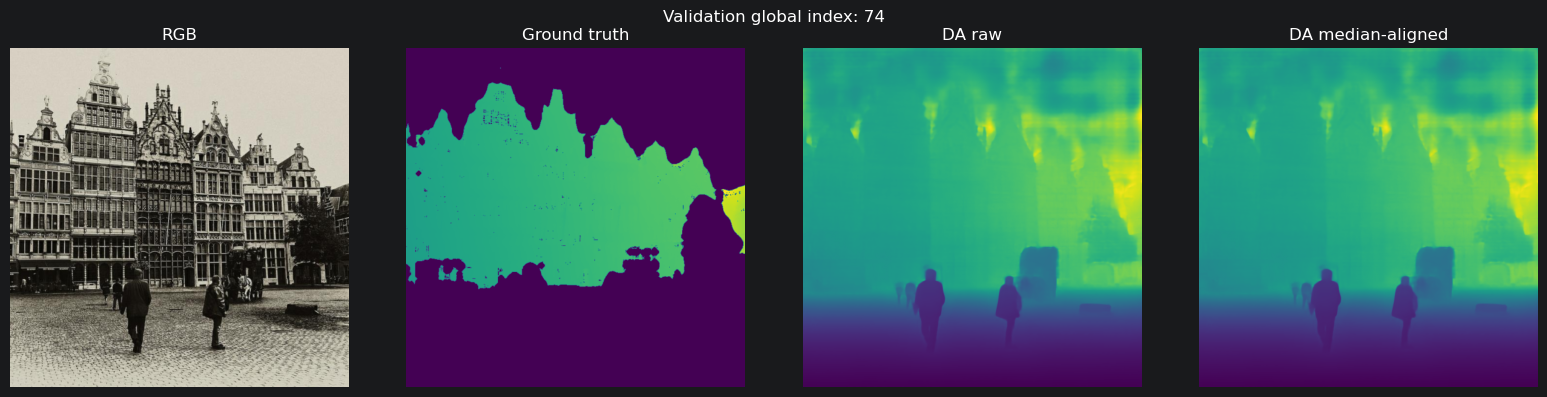

In [12]:
def to_numpy_image(img):
    img = img.detach().cpu()
    if img.ndim == 3 and img.shape[0] in (1, 3):
        img = img.permute(1, 2, 0)
    img = img.numpy()
    if img.max() > 1.5:
        img = img / 255.0
    return np.clip(img, 0, 1)


def to_numpy_depth(depth):
    depth = squeeze_depth(depth.detach().cpu())
    if depth.ndim == 3:
        depth = depth[0]
    return depth.numpy()


def show_examples(num_examples=4):
    batch = next(iter(val_loader))
    images = batch['image'].to(DEVICE)
    targets = batch['depth'].to(DEVICE)

    with torch.no_grad():
        images_for_da = images / 255.0 if NORMALIZE_IMAGES_FOR_DA else images
        preds = da_model(images_for_da)
        preds, targets = resize_pred_to_target(preds, targets)
        preds_median = median_align(preds, targets)

    n = min(num_examples, images.shape[0])

    for i in range(n):
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        fig.suptitle(f'Validation global index: {val_indices[i]}')

        axes[0].imshow(to_numpy_image(images[i]))
        axes[0].set_title('RGB')
        axes[0].axis('off')

        axes[1].imshow(to_numpy_depth(targets[i]), cmap='viridis')
        axes[1].set_title('Ground truth')
        axes[1].axis('off')

        axes[2].imshow(to_numpy_depth(preds[i]), cmap='viridis')
        axes[2].set_title('DA raw')
        axes[2].axis('off')

        axes[3].imshow(to_numpy_depth(preds_median[i]), cmap='viridis')
        axes[3].set_title('DA median-aligned')
        axes[3].axis('off')

        plt.tight_layout()
        plt.show()

show_examples(num_examples=4)

In [13]:
for name, param in da_model.named_parameters():
    print(name)

pretrained.cls_token
pretrained.pos_embed
pretrained.mask_token
pretrained.patch_embed.proj.weight
pretrained.patch_embed.proj.bias
pretrained.blocks.0.norm1.weight
pretrained.blocks.0.norm1.bias
pretrained.blocks.0.attn.qkv.weight
pretrained.blocks.0.attn.qkv.bias
pretrained.blocks.0.attn.proj.weight
pretrained.blocks.0.attn.proj.bias
pretrained.blocks.0.ls1.gamma
pretrained.blocks.0.norm2.weight
pretrained.blocks.0.norm2.bias
pretrained.blocks.0.mlp.fc1.weight
pretrained.blocks.0.mlp.fc1.bias
pretrained.blocks.0.mlp.fc2.weight
pretrained.blocks.0.mlp.fc2.bias
pretrained.blocks.0.ls2.gamma
pretrained.blocks.1.norm1.weight
pretrained.blocks.1.norm1.bias
pretrained.blocks.1.attn.qkv.weight
pretrained.blocks.1.attn.qkv.bias
pretrained.blocks.1.attn.proj.weight
pretrained.blocks.1.attn.proj.bias
pretrained.blocks.1.ls1.gamma
pretrained.blocks.1.norm2.weight
pretrained.blocks.1.norm2.bias
pretrained.blocks.1.mlp.fc1.weight
pretrained.blocks.1.mlp.fc1.bias
pretrained.blocks.1.mlp.fc2.weight

## Trained Depth Anything